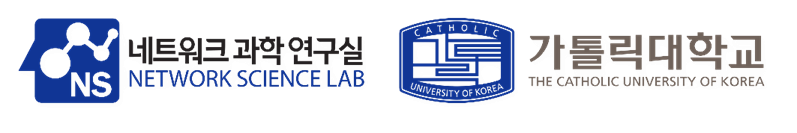

# 🌌 Graph Mining: Patterns & Isomorphisms
Welcome to Week 7! In this notebook, we'll dive deep into **Graph Substructures**, **Frequent Subgraph Mining** (gSpan), and **Graph Compression** (Subdue). 

Let's start by looking at **Graph Isomorphisms**—the mathematical way of asking if two graphs have the exact same structure!

### 🧩 1. Graph Isomorphism
The `is_isomorphic` function in NetworkX returns `True` if two graphs $G1$ and $G2$ share the same connectivity and structure, and `False` otherwise.
*(Note: The two graphs must be of the same type).*

In [ ]:
# Install necessary libraries
%pip install networkx matplotlib gspan-mining

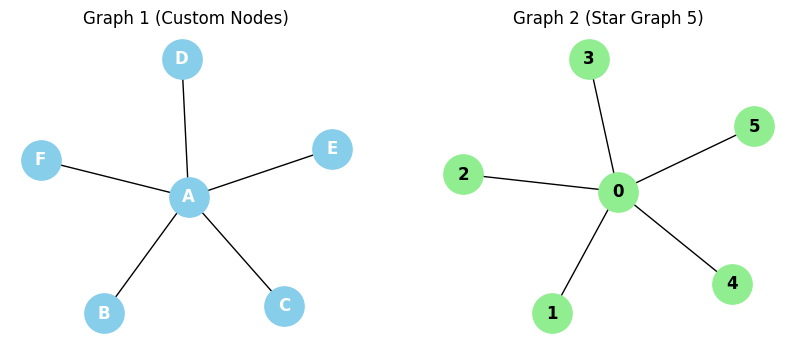

In [1]:
import networkx as nx
import networkx.algorithms.isomorphism as iso
import matplotlib.pyplot as plt

# 🎨 Set a nice color palette
node_color_g1 = 'skyblue'
node_color_g2 = 'lightgreen'

# Create graph 1 (A custom star-like shape)
graph_1 = nx.Graph()
graph_1.add_nodes_from(['A','B','C','D','E','F'])
graph_1.add_edges_from([('A','B'),('A','C'),('A','D'),('A','E'),('A','F')])

# Create graph 2 (A built-in 5-star graph)
star_graph_2 = nx.star_graph(5)

# Visualizing our graphs side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

nx.draw(graph_1, with_labels=True, node_color=node_color_g1, node_size=800, 
        font_weight='bold', font_color='white', ax=axes[0])
axes[0].set_title("Graph 1 (Custom Nodes)")

nx.draw(star_graph_2, with_labels=True, node_color=node_color_g2, node_size=800, 
        font_weight='bold', font_color='black', ax=axes[1])
axes[1].set_title("Graph 2 (Star Graph 5)")

plt.show()

## 1.1. Testing if two graphs are isomorphic

In [2]:
# 1.1. Testing if two graphs are isomorphic
is_isomorphic = nx.is_isomorphic(graph_1, star_graph_2)
print(f"✨ Are Graph 1 and Graph 2 isomorphic? -> {is_isomorphic}")

✨ Are Graph 1 and Graph 2 isomorphic? -> True


## 1.2 NetworkX isomorphism - how to find edge mapping

In [3]:
# 1.2 NetworkX Isomorphism - Analyzing Edge Mappings
# Let's see how attributes affect isomorphisms

import networkx as nx

G1_weighted = nx.Graph()
G1_weighted.add_weighted_edges_from([(0,1,0), (0,2,1), (0,3,2)], weight='aardvark')

G2_weighted = nx.Graph()
G2_weighted.add_weighted_edges_from([(0,1,0), (0,2,2), (0,3,1)], weight='baboon')

G3_weighted = nx.Graph()
G3_weighted.add_weighted_edges_from([(0,1,0), (0,2,2), (0,3,2)], weight='baboon')

def match_animal_weights(attr1, attr2):    
    # Tests if the 'aardvark' attribute of an edge equals the 'baboon' attribute.
    return attr1.get('aardvark') == attr2.get('baboon')

print(f"Match G1 and G2 based on animal weights? -> {nx.is_isomorphic(G1_weighted, G2_weighted, edge_match=match_animal_weights)}")

Match G1 and G2 based on animal weights? -> True


In [4]:
print(f"Match G1 and G3 based on animal weights? -> {nx.is_isomorphic(G1_weighted, G3_weighted, edge_match=match_animal_weights)}")

Match G1 and G3 based on animal weights? -> False


# 🕸️ 2. gSpan Method
gSpan helps us find **Frequent Subgraphs** across a large graph database.

> **📂 Data File Format (gSpan/graphdata/)**
> - 📄 `t # N` : The N-th graph.
> - 🔵 `v M L` : The M-th vertex in this graph has label L.
> - ➖ `e P Q L` : Edge connecting P-th and Q-th vertex with label L.

In [5]:
from gspan_mining.config import parser
from gspan_mining.main import main

In [6]:
%matplotlib inline


In [7]:
args_str = '-s 2 -d True -l 5 -p True -w True graphdata/graph.data.simple.5'
FLAGS, _ = parser.parse_known_args(args=args_str.split())

⚠️ **Pandas Deprecation Note:**
Pandas >2.0 removed `concat` as used by older gSpan versions. Ensure you've patched `gspan_mining/gspan.py` in your environment (around line 335) and restarted VS Code!

t # 0
v 0 2
v 1 2
v 2 3
v 3 4
v 4 2
e 0 1 2
e 0 4 2
e 1 2 3
e 2 3 2

Support: 2


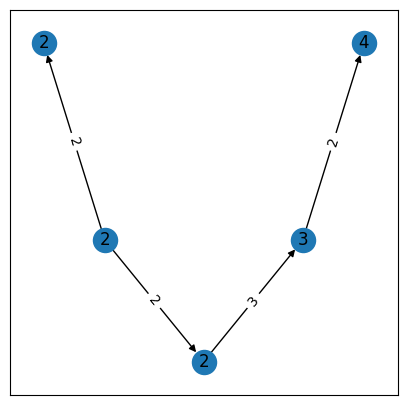

where: [0, 3]

-----------------

t # 1
v 0 2
v 1 2
v 2 2
v 3 3
v 4 4
e 0 1 2
e 1 2 2
e 1 3 3
e 3 4 2

Support: 2


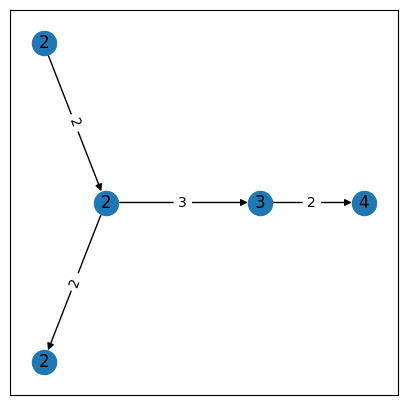

where: [0, 3]

-----------------

t # 2
v 0 2
v 1 2
v 2 2
v 3 3
v 4 4
v 5 2
e 0 1 2
e 0 5 2
e 1 2 2
e 1 3 3
e 3 4 2

Support: 2


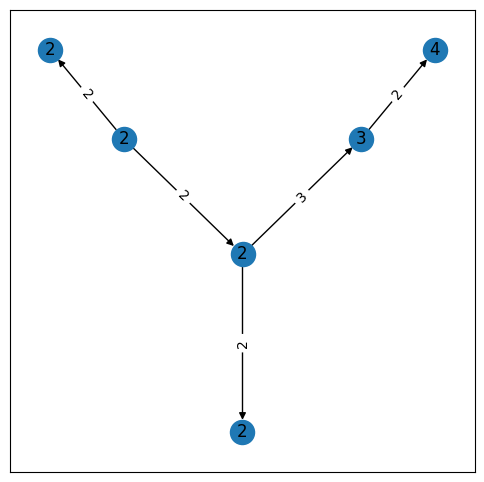

where: [0, 3]

-----------------

t # 3
v 0 2
v 1 2
v 2 2
v 3 3
v 4 2
e 0 1 2
e 0 4 2
e 1 2 2
e 1 3 3

Support: 2


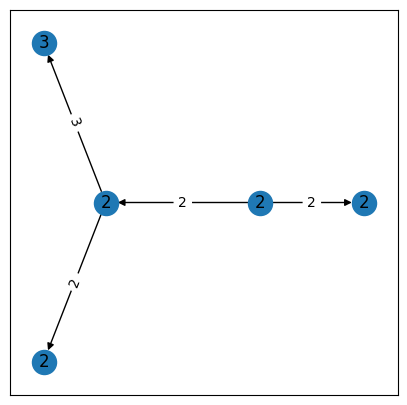

where: [0, 3]

-----------------

Read:	0.0 s
Mine:	0.29 s
Total:	0.29 s


In [8]:
gs = main(FLAGS)
print(gs)

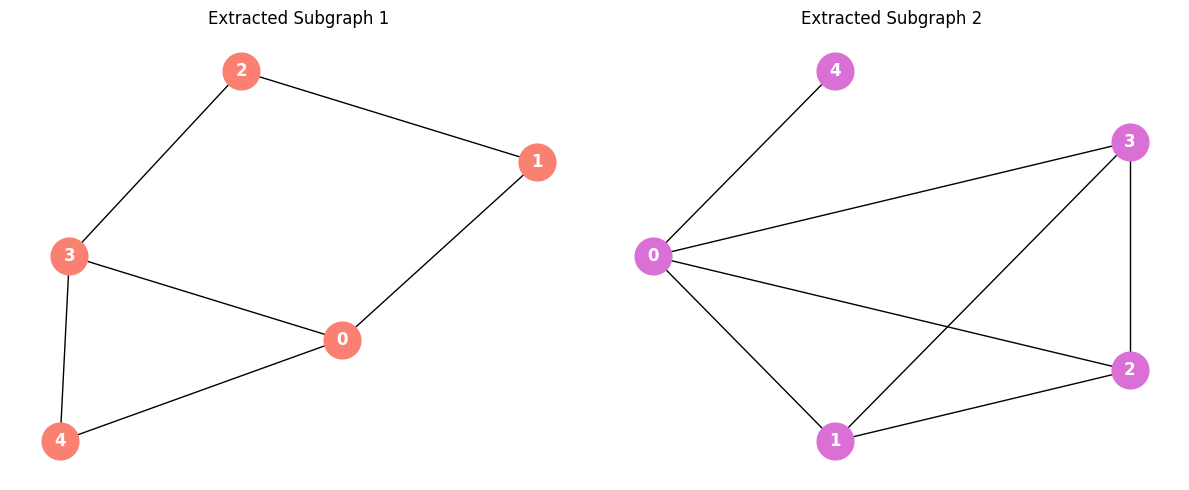

In [16]:
# Convert gSpan graph object -> NetworkX graph
def gspan_to_nx(g):
    G = nx.Graph()
    for vid, v in g.vertices.items():
        G.add_node(vid)
    for vid, v in g.vertices.items():
        for to_vid, e in v.edges.items():
            if not G.has_edge(vid, to_vid):
                G.add_edge(vid, to_vid)
    return G

# Visualize first two graphs safely
num_to_plot = min(2, len(gs.graphs))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
if num_to_plot == 1:
    axes = [axes[0], axes[1]]

if num_to_plot >= 1:
    g1_plot = gspan_to_nx(gs.graphs[0])
    nx.draw(
        g1_plot, pos=nx.spring_layout(g1_plot), with_labels=True,
        node_color='salmon', node_size=700, font_weight='bold',
        font_color='white', ax=axes[0]
    )
    axes[0].set_title("Extracted Subgraph 1")

if num_to_plot >= 2:
    g2_plot = gspan_to_nx(gs.graphs[1])
    nx.draw(
        g2_plot, pos=nx.shell_layout(g2_plot), with_labels=True,
        node_color='orchid', node_size=700, font_weight='bold',
        font_color='white', ax=axes[1]
    )
    axes[1].set_title("Extracted Subgraph 2")

# Hide unused subplot if needed
if num_to_plot < 2:
    axes[1].axis('off')

plt.tight_layout()
plt.show()

In [10]:
args_str = '-s 2 -l 3 -p True graphdata/sample_data3'
FLAGS, _ = parser.parse_known_args(args=args_str.split())

t # 0
v 0 A
v 1 B
v 2 C
e 0 1 1
e 1 2 1

Support: 2


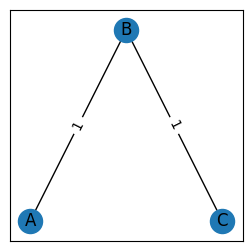


-----------------

t # 1
v 0 A
v 1 B
v 2 A
e 0 1 1
e 1 2 1

Support: 2


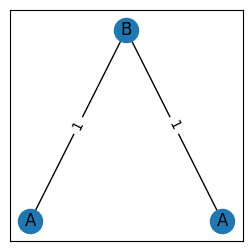


-----------------

t # 2
v 0 A
v 1 B
v 2 A
v 3 C
e 0 1 1
e 1 2 1
e 1 3 1

Support: 2


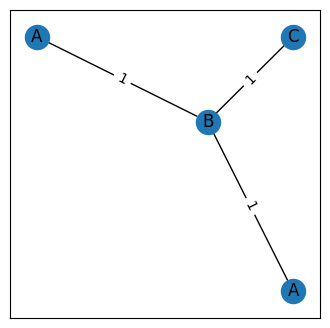


-----------------

t # 3
v 0 A
v 1 A
v 2 B
e 0 1 1
e 1 2 1

Support: 2


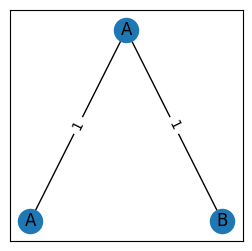


-----------------

t # 4
v 0 A
v 1 A
v 2 B
e 0 1 1
e 0 2 1
e 1 2 1

Support: 2


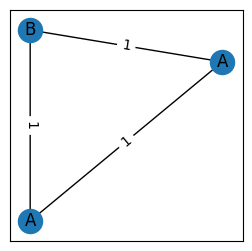


-----------------

t # 5
v 0 A
v 1 A
v 2 B
v 3 C
e 0 1 1
e 0 2 1
e 1 2 1
e 2 3 1

Support: 2


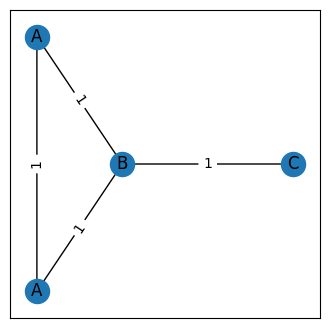


-----------------

t # 6
v 0 A
v 1 A
v 2 B
v 3 C
e 0 1 1
e 1 2 1
e 2 3 1

Support: 2


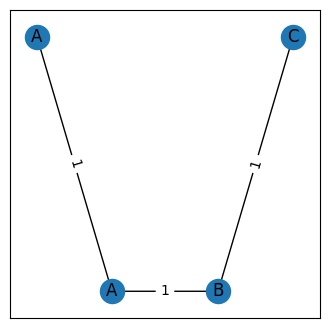


-----------------

Read:	0.0 s
Mine:	0.39 s
Total:	0.39 s


In [11]:
gs = main(FLAGS)
print(gs)

# 🗜️ 3. Subdue Algorithm
Subdue operates by finding subgraphs (motifs) that minimize the **Minimum Description Length (MDL)** of the graph, effectively compressing the original graph!

⬇️ *Ensure you are using the provided `Subdue_mining` module from Github.*

In [12]:
import os
import subprocess
import json
import re
import contextlib
import io
import sys
import networkx as nx

from Subdue_mining import Parameters
from Subdue_mining.Subdue import ReadGraph, Subdue, nx_subdue

subdue_example_path = './graphdata/inputgraph.json'
tolerance_pct = 0.1  # mainly due to non-deterministic nature of the algorithm

def subdue_json_to_undirected_nx_graph(subdue_json_path):
    with open(subdue_json_path, 'r') as subdue_json_file:
        subdue_format = json.load(subdue_json_file)

    graph = nx.Graph()
    for vertex_or_edge in subdue_format:
        if list(vertex_or_edge.keys()) == ['vertex']:
            node_attributes_loop = vertex_or_edge['vertex']['attributes']
            graph.add_node(
                vertex_or_edge['vertex']['id'],
                **node_attributes_loop,
            )
        elif list(vertex_or_edge.keys()) == ['edge']:
            edge_attributes_loop = vertex_or_edge['edge']['attributes']
            graph.add_edge(
                u_of_edge=vertex_or_edge['edge']['source'],
                v_of_edge=vertex_or_edge['edge']['target'],
                **edge_attributes_loop,
            )
        else:
            raise ValueError('Invalid entry type')

    return graph

# use networkx graph as an input
subdue_example_graph = subdue_json_to_undirected_nx_graph(subdue_example_path)
capture_prints = io.StringIO()
with contextlib.redirect_stdout(capture_prints):
    result = nx_subdue(graph=subdue_example_graph, verbose=True)
prints_nx_subdue = capture_prints.getvalue()


In [13]:
prints_nx_subdue

'Graph: 15 vertices, 15 edges\n7 patterns left\n4 patterns left\n1 patterns left\nNo more patterns to consider\n\nBest 3 patterns:\n\n  Pattern (value=0.8, instances=5):\n    Graph:\n      vertex "1": timestamp=0, label=v1\n      vertex "2": timestamp=0, label=v2\n      vertex "3": timestamp=0, label=v3\n      edge "1" (1--2): timestamp=0, label=e12\n      edge "2" (1--3): timestamp=0, label=e13\n      edge "3" (2--3): timestamp=0, label=e23\n    Instance 1:\n      vertex "1": timestamp=0, label=v1\n      vertex "2": timestamp=0, label=v2\n      vertex "3": timestamp=0, label=v3\n      edge "1-2" (1--2): timestamp=0, label=e12\n      edge "1-3" (1--3): timestamp=0, label=e13\n      edge "2-3" (2--3): timestamp=0, label=e23\n    Instance 2:\n      vertex "4": timestamp=0, label=v1\n      vertex "5": timestamp=0, label=v2\n      vertex "6": timestamp=0, label=v3\n      edge "4-5" (4--5): timestamp=0, label=e12\n      edge "4-6" (4--6): timestamp=0, label=e13\n      edge "5-6" (5--6): tim

In [14]:
result

[[{'nodes': ['1', '2', '3'], 'edges': [('1', '2'), ('1', '3'), ('2', '3')]},
  {'nodes': ['4', '5', '6'], 'edges': [('4', '5'), ('4', '6'), ('5', '6')]},
  {'nodes': ['7', '8', '9'], 'edges': [('7', '8'), ('7', '9'), ('8', '9')]},
  {'nodes': ['10', '11', '12'],
   'edges': [('10', '11'), ('10', '12'), ('11', '12')]},
  {'nodes': ['13', '14', '15'],
   'edges': [('13', '14'), ('13', '15'), ('14', '15')]}],
 [{'nodes': ['1', '2', '3'], 'edges': [('1', '2'), ('1', '3')]},
  {'nodes': ['4', '5', '6'], 'edges': [('4', '5'), ('4', '6')]},
  {'nodes': ['7', '8', '9'], 'edges': [('7', '8'), ('7', '9')]},
  {'nodes': ['10', '11', '12'], 'edges': [('10', '11'), ('10', '12')]},
  {'nodes': ['13', '14', '15'], 'edges': [('13', '14'), ('13', '15')]}],
 [{'nodes': ['1', '2', '3'], 'edges': [('1', '2'), ('2', '3')]},
  {'nodes': ['4', '5', '6'], 'edges': [('4', '5'), ('5', '6')]},
  {'nodes': ['7', '8', '9'], 'edges': [('7', '8'), ('8', '9')]},
  {'nodes': ['10', '11', '12'], 'edges': [('10', '11'),

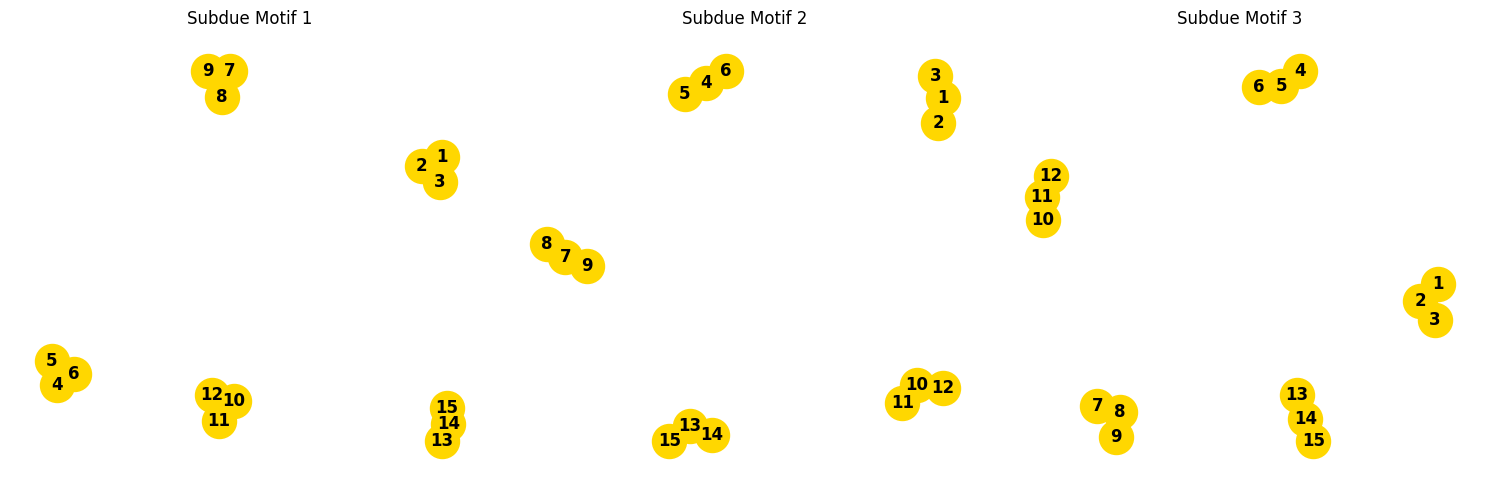

In [27]:
import matplotlib.pyplot as plt
import math

# Create a sequence of extracted motifs
graphs = []
for graph_data in result:
    G_motif = nx.Graph()
    for subgraph_data in graph_data:
        G_motif.add_nodes_from(subgraph_data['nodes'])
        G_motif.add_edges_from(subgraph_data['edges'])
    graphs.append(G_motif)

# Display them in a beautiful dynamic grid structure!
n_graphs = len(graphs)
cols = 3
if n_graphs > 0:
    rows = math.ceil(n_graphs / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    if n_graphs > 1:
        axes = axes.flatten()
    else:
        axes = [axes] # standardize to list

    for i, G_motif in enumerate(graphs):
        ax = axes[i]
        nx.draw(G_motif, pos=nx.spring_layout(G_motif), with_labels=True, 
                node_color='gold', node_size=600, edge_color='gray', font_weight='bold', ax=ax)
        ax.set_title(f"Subdue Motif {i+1}")
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No motifs found.")